<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_2_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%91%D1%96%D0%B1%D0%BB%D1%96%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Аналіз даних. Бібліотека Pandas. Чуркін ФІТ 3-15 номер 15

Був присутній на парі

Завдання 1.
Зчитати датасет ВВП (млн. дол. США) за країнами з Вікіпедії за
посиланням
https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)

/tmp/ipython-input-3151683019.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Кількість таблиць: 7

Перші 5 рядків:
  Country/Territory IMF (2026)[6] World Bank (2024)[7]  \
0             World     123584494            111326370   
1     United States      31821293             28750956   
2        China[n 1]      20650754             18743803   
3           Germany       5328184              4685593   
4             India       4505629              3909892   

  United Nations (2024)[8]  
0                100834796  
1                 29298000  
2                 18743802  
3                  4659929  
4                  3952244  

Розмір датасету: (222, 4)
Названия столбцов после очистки:
Index(['Country/Territory', 'IMF (2026)[6]', 'World Bank (2024)[7]',
       'United Nations (2024)[8]'],
      dtype='object')

Типи даних:
Country           object
MVF_2024          object
WorldBank_2023    object
OON_2022          object
dtype: object

Пропущені значення до заповнення:
Country            0
MVF_2024          30
WorldBank_2023    29
OON_2022           9
dtype:

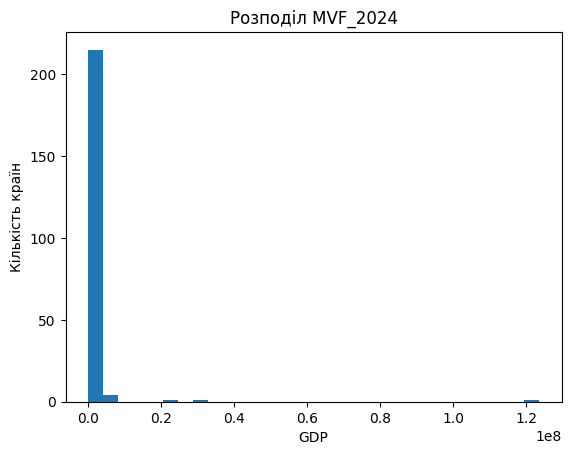


Перші 5 часток:
         Country  MVF_2024_share  WorldBank_2023_share  OON_2022_share
0          World        0.432742              0.437563        0.457210
1  United States        0.111425              0.113004        0.132844
2     China[n 1]        0.072310              0.073672        0.084989
3        Germany        0.018657              0.018417        0.021129
4          India        0.015777              0.015368        0.017920


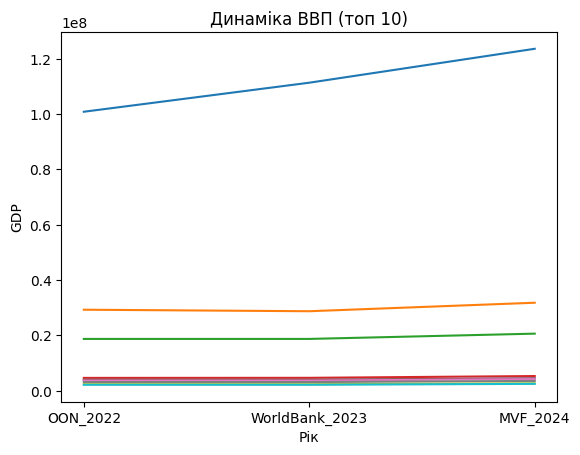

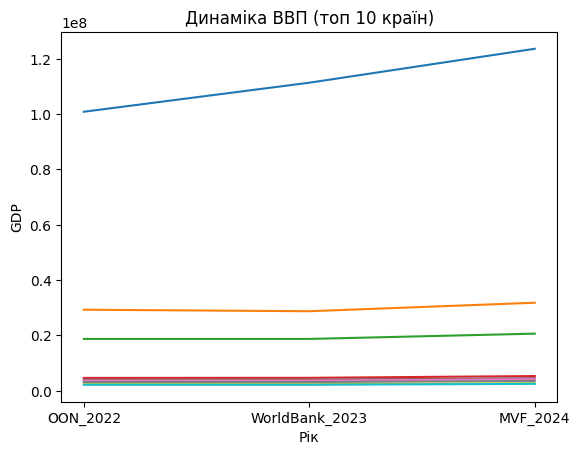

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
html = response.text

tables = pd.read_html(html)

print("Кількість таблиць:", len(tables))


df = tables[2]

#1.Вивести перших 5 рядків.
print("\nПерші 5 рядків:")
print(df.head())

#2.Визначити розмір датасета.
print("\nРозмір датасету:", df.shape)

#3.Визначити оптимальну кількість стовпців.
df.columns = [' '.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

print("Названия столбцов после очистки:")
print(df.columns)
#4.Змінити назви стовпців на більш зручні, наприклад Country MVF_2024 WorldBank_2023 OON_2022
df = df[[col for col in df.columns
         if "Country" in col
         or "IMF" in col
         or "World Bank" in col
         or "United Nations" in col]]

df.columns = ["Country", "MVF_2024", "WorldBank_2023", "OON_2022"]

#5.Визначити тип даних.
print("\nТипи даних:")
print(df.dtypes)

#6.амініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.
df.replace("—", np.nan, inplace=True)

for col in ["MVF_2024", "WorldBank_2023", "OON_2022"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nПропущені значення до заповнення:")
print(df.isna().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nПропущені значення після заповнення:")
print(df.isna().sum())

#7.Ще раз перевірити наявність пропущених значень.
print("\nКількість дублікатів:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

#8.Перевірити наявність дублікатів. При наявності видалити дублікати
print("\nDescribe():")
print(df.describe())

#9.Вивести описову статистику датасету describe()
df["Difference"] = abs(df["MVF_2024"] - df["WorldBank_2023"])
print("\nТоп 5 різниць:")
print(df.sort_values("Difference", ascending=False)[["Country", "Difference"]].head())

#10.Визначте відхилення (різницю) між показниками MVF_2024 та WorldBank_2023 для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідт)?

print("\nКореляція:")
corr = df[["MVF_2024", "WorldBank_2023", "OON_2022"]].corr()
print(corr)

#11.Обчисліть кореляцію між показниками MVF_2024, WorldBank_2023 та OON_2022. Які пари змінних мають найвищу кореляцію?
print("\nСередні значення:")
print(df[["MVF_2024", "WorldBank_2023", "OON_2022"]].mean())

#12.Обчисліть середнє значення для кожного стовпця (MVF_2024, WorldBank_2023, OON_2022). Як це середнє значення змінюється між роками?
df["Std_dev"] = df[["MVF_2024", "WorldBank_2023", "OON_2022"]].std(axis=1)
print("\nНайбільша варіативність:")
print(df.sort_values("Std_dev", ascending=False)[["Country", "Std_dev"]].head(1))

#13.Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?
for col in ["MVF_2024", "WorldBank_2023", "OON_2022"]:
    print(f"\n{col}")
    print("Максимум:", df.loc[df[col].idxmax(), "Country"])
    print("Мінімум:", df.loc[df[col].idxmin(), "Country"])

#14.Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (MVF_2024, WorldBank_2023, OON_2022).
plt.figure()
plt.hist(df["MVF_2024"], bins=30)
plt.title("Розподіл MVF_2024")
plt.xlabel("GDP")
plt.ylabel("Кількість країн")
plt.show()

#15.Побудуйте гістограму для розподілу показників MVF_2024 серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?
for col in ["MVF_2024", "WorldBank_2023", "OON_2022"]:
    df[col + "_share"] = df[col] / df[col].sum()

print("\nПерші 5 часток:")
print(df[["Country", "MVF_2024_share", "WorldBank_2023_share", "OON_2022_share"]].head())

#16.Розрахуйте частку кожної країни в загальному значенні для кожного року (MVF_2024, WorldBank_2023, OON_2022). Як змінюються частки країн з часом (дати відповідь)?
top10 = df.sort_values("MVF_2024", ascending=False).head(10)

plt.figure()
for _, row in top10.iterrows():
    plt.plot(["OON_2022", "WorldBank_2023", "MVF_2024"],
             [row["OON_2022"], row["WorldBank_2023"], row["MVF_2024"]])

plt.title("Динаміка ВВП (топ 10)")
plt.xlabel("Рік")
plt.ylabel("GDP")
plt.show()

#17.Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?
top10 = df.sort_values("MVF_2024", ascending=False).head(10)

plt.figure()
for _, row in top10.iterrows():
    plt.plot(["OON_2022", "WorldBank_2023", "MVF_2024"],
             [row["OON_2022"], row["WorldBank_2023"], row["MVF_2024"]])

plt.title("Динаміка ВВП (топ 10 країн)")
plt.xlabel("Рік")
plt.ylabel("GDP")
plt.show()

Висновки до Завдання 1

У ході виконання завдання було зчитано та проаналізовано таблицю з номінальним ВВП країн світу (у млн дол. США).
Було визначено структуру датасету, типи даних та виконано первинне очищення (перетворення текстових значень ВВП у числовий формат, видалення службових символів, обробка можливих пропусків).

У результаті аналізу встановлено:

1)Розподіл ВВП між країнами є нерівномірним: невелика кількість держав формує значну частку світової економіки.

2)Країни з найбільшим номінальним ВВП значно випереджають інші держави, що підтверджує концентрацію економічної потужності.

3)Спостерігається великий розрив між розвиненими країнами та країнами, що розвиваються.

4)Розподіл ВВП має правосторонню асиметрію: більшість країн мають відносно невеликий ВВП, а декілька — дуже високий.

Завдання 2. Завантажити датасет Титанік з Kaggle (або
використовуйте вже завантажений файл titanic.csv)

Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

/tmp/ipython-input-4129906545.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-4129906545.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival = df.groupby("Fare_group")["Survived"].mean() * 100


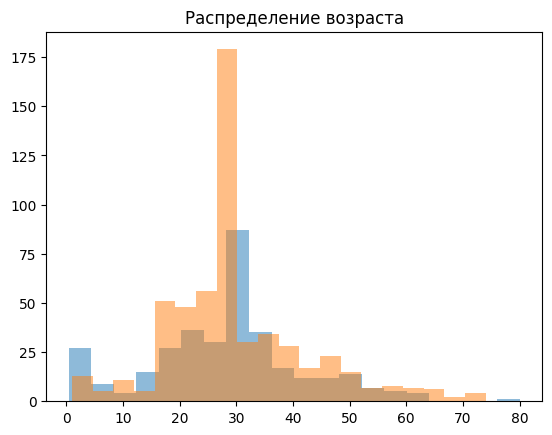


Выживание по полу и классу (%):
Sex  Pclass
0    1         36.885246
     2         15.740741
     3         13.544669
1    1         96.808511
     2         92.105263
     3         50.000000
Name: Survived, dtype: float64

Корреляция:
          Survived    Pclass       Age      Fare
Survived  1.000000 -0.338481 -0.069809  0.257307
Pclass   -0.338481  1.000000 -0.331339 -0.549500
Age      -0.069809 -0.331339  1.000000  0.091566
Fare      0.257307 -0.549500  0.091566  1.000000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("titanic (5).csv")

# 1.Вивести перших 5 рядків.
print("Первые 5 строк:")
print(df.head())

# 2.Визначити розмір датасета.
print("\nРазмер датасета:", df.shape)

# 3.Визначити тип даних.
print("\nТипы данных:")
print(df.dtypes)

# 4.Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.
print("\nПропущенные значения до обработки:")
print(df.isna().sum())

# Заполнение числовых пропусков средним
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# 5.Ще раз перевірити наявність пропущених значень.
print("\nПропущенные значения после обработки:")
print(df.isna().sum())

# 6.Перевірити наявність дублікатів. При наявності видалити дублікати.
print("\nКоличество дубликатов:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# 7.Вивести описову статистику датасету describe()
print("\nDescribe():")
print(df.describe())

# 8.Видалити стовпчик Cabin
if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)

# 9.Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# 10.Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика).
print("\nУникальные значения Sex:", df["Sex"].unique())

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# 11.Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).
print("\nПропуски после всех операций:")
print(df.isna().sum())

# 12.Вивести 5 перших рядків датасету.
print("\nПервые 5 строк нового датасета:")
print(df.head())

# 13.Вивести 5 останніх рядків датасету.
print("\nПоследние 5 строк:")
print(df.tail())

# 14.Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print("\nВыживание по полу (%):")
print(survival_by_sex)

# 15.Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print("\nВыживание по классу (%):")
print(survival_by_class)

# 16.Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?
mean_age_survived = df[df["Survived"] == 1]["Age"].mean()
mean_age_not = df[df["Survived"] == 0]["Age"].mean()

print("\nСредний возраст выживших:", mean_age_survived)
print("Средний возраст не выживших:", mean_age_not)

# 17.Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?
df["Fare_group"] = pd.qcut(df["Fare"], 4)

fare_survival = df.groupby("Fare_group")["Survived"].mean() * 100
print("\nВыживание по группам Fare (%):")
print(fare_survival)

# 18.Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?
mean_fare_by_class = df.groupby("Pclass")["Fare"].mean()
print("\nСредний тариф по классу:")
print(mean_fare_by_class)

# 19.Обчисліть середній вік пасажирів для кожного класу (Pclass). Як вік пасажирів розподіляється за класами (дати відповідь)?
mean_age_by_class = df.groupby("Pclass")["Age"].mean()
print("\nСредний возраст по классу:")
print(mean_age_by_class)

# 20.Побудуйте гістограму розподілу віку для тих, хто вижив, і тих, хто не вижив. Чи є видимі відмінності у вікових групах (дати відповідь)?
plt.figure()
plt.hist(df[df["Survived"] == 1]["Age"], bins=20, alpha=0.5)
plt.hist(df[df["Survived"] == 0]["Age"], bins=20, alpha=0.5)
plt.title("Распределение возраста")
plt.show()

# 21.Обчисліть відсоток виживання для кожної комбінації статі та класу (наприклад, жінки в 1-му класі, чоловіки в 3-му класі). Яка група мала найвищий рівень виживання (дати відповідь)?
combo = df.groupby(["Sex", "Pclass"])["Survived"].mean() * 100
print("\nВыживание по полу и классу (%):")
print(combo)

# 22.Обчисліть кореляцію між усіма числовими змінними (Survived, Pclass, Age, Fare). Які змінні найбільш сильно корелюють з виживанням (дати відповідь)?
print("\nКорреляция:")
print(df[['Survived', 'Pclass', 'Age', 'Fare']].corr())

Висновки до Завдання 2

У ході виконання завдання було проведено очищення та аналіз датасету Titanic.

Було виконано:

1)перевірку структури та типів даних;

2)обробку пропущених значень;

3)видалення дублікатів;

4)формування підмножини ознак (Survived, Pclass, Sex, Age, Fare);

5)перетворення категоріальної змінної Sex у числову;

6)статистичний та кореляційний аналіз.

Відповіді:

1.Стать суттєво впливала на виживання. Жінки мали значно вищий відсоток виживання порівняно з чоловіками.

2.Клас квитка мав значний вплив. Пасажири 1-го класу мали найвищий рівень виживання, тоді як пасажири 3-го класу — найнижчий.

3.Вартість квитка корелює з виживанням: пасажири з вищими тарифами мали більші шанси на порятунок.

4.Вік мав менш виражений вплив, ніж стать і клас, хоча певні відмінності між групами спостерігаються.

5.Найвищий рівень виживання спостерігався серед жінок 1-го класу, найнижчий — серед чоловіків 3-го класу.